# Experiment 9 — Perceptron vs Multilayer Perceptron (A/B Experiment)

**Course:** ICS1512 – Machine Learning Algorithms Laboratory  
**Experiment:** 9 — Perceptron vs Multilayer Perceptron with Hyperparameter Tuning

This notebook follows the assignment requirements:
- preprocess the English Handwritten Characters dataset;
- implement a **multiclass Perceptron Learning Algorithm (PLA) from scratch**;
- train and tune an **MLP** using backpropagation;
- compare the two models using Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC curves, and convergence curves;
- analyze the effect of activation, optimizer, learning rate, batch size, architecture, and overfitting.

The supplied dataset contains 62 classes with 55 images per class (3,410 images total).

## 1. Imports and configuration

The default image size is reduced to **28 × 28** before flattening. This keeps the experiment practical while preserving the overall character shape.

For the 62-class problem, PLA is implemented as a **multiclass perceptron** with one weight vector per class.

In [1]:
import os
import zipfile
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
IMG_SIZE = (28, 28)
TEST_SIZE = 0.20
VAL_SIZE = 0.15
FIGURES_DIR = Path("figures9")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
# Locate dataset zip
zip_candidates = [
    Path("archive (6).zip"),
    Path("Assignment 9/archive (6).zip"),
    Path("/content/archive (6).zip")
]
DATASET_ZIP = None
for c in zip_candidates:
    if c.exists():
        DATASET_ZIP = c
        break
if DATASET_ZIP is None:
    DATASET_ZIP = Path("/content/archive (6).zip")
print("Using DATASET_ZIP =", DATASET_ZIP)
np.random.seed(RANDOM_STATE)
print("Configuration ready.")


Using DATASET_ZIP = Assignment 9\archive (6).zip
Configuration ready.


## 2. Dataset loading

The ZIP is expected to contain files of the form:

`Img/img001-001.png`, `Img/img001-002.png`, …, `Img/img062-055.png`

The assignment defines the classes as:

`0–9, A–Z, a–z`

Therefore `img001` is mapped to `0`, …, `img010` to `9`, `img011` to `A`, …, and `img062` to `z`.

In [2]:
CLASS_NAMES = list("0123456789") + list("ABCDEFGHIJKLMNOPQRSTUVWXYZ") + list("abcdefghijklmnopqrstuvwxyz")
assert len(CLASS_NAMES) == 62

def load_handwritten_dataset(zip_path, img_size=IMG_SIZE):
    zip_path = Path(zip_path)
    if not zip_path.exists():
        raise FileNotFoundError(
            f"Dataset ZIP not found: {zip_path}\n"
            "In Colab, upload the ZIP or change DATASET_ZIP to its location."
        )

    X, y = [], []

    with zipfile.ZipFile(zip_path, "r") as z:
        image_files = [
            name for name in z.namelist()
            if name.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        for name in sorted(image_files):
            filename = Path(name).name
            prefix = filename.split("-")[0]   # e.g. img001

            if not prefix.startswith("img"):
                continue

            class_id = int(prefix[3:]) - 1

            with z.open(name) as f:
                img = Image.open(f).convert("L")
                img = img.resize(img_size)
                arr = np.asarray(img, dtype=np.float32) / 255.0

            X.append(arr.reshape(-1))
            y.append(class_id)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)

    return X, y

X, y = load_handwritten_dataset(DATASET_ZIP)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", len(np.unique(y)))
print("Class distribution:")
print(pd.Series(y).value_counts().sort_index().to_string())


X shape: (3410, 784)
y shape: (3410,)
Number of classes: 62
Class distribution:
0     55
1     55
2     55
3     55
4     55
5     55
6     55
7     55
8     55
9     55
10    55
11    55
12    55
13    55
14    55
15    55
16    55
17    55
18    55
19    55
20    55
21    55
22    55
23    55
24    55
25    55
26    55
27    55
28    55
29    55
30    55
31    55
32    55
33    55
34    55
35    55
36    55
37    55
38    55
39    55
40    55
41    55
42    55
43    55
44    55
45    55
46    55
47    55
48    55
49    55
50    55
51    55
52    55
53    55
54    55
55    55
56    55
57    55
58    55
59    55
60    55
61    55


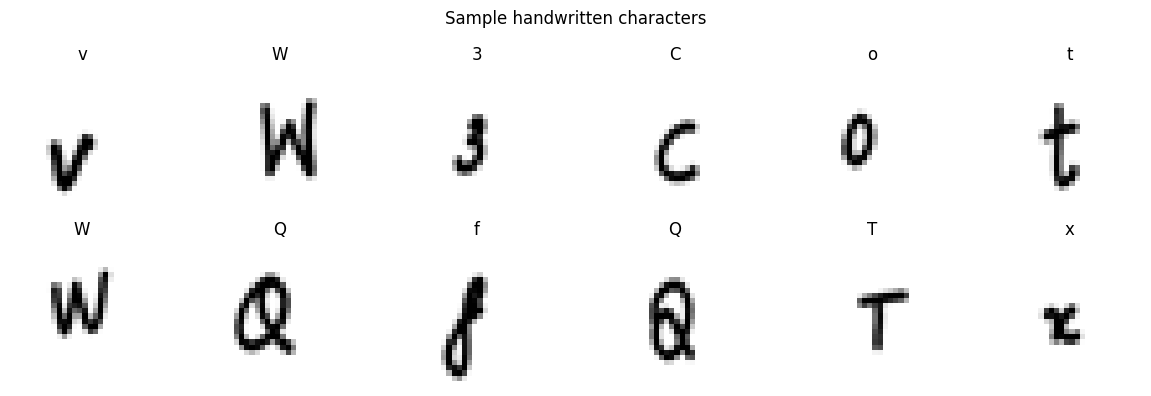

In [3]:
# Display a few samples
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, idx in zip(axes.ravel(), np.random.choice(len(X), 12, replace=False)):
    ax.imshow(X[idx].reshape(IMG_SIZE), cmap="gray")
    ax.set_title(CLASS_NAMES[y[idx]])
    ax.axis("off")
plt.suptitle("Sample handwritten characters")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sample_characters.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Train / validation / test split

A stratified split is used so that all 62 classes are represented proportionally.

- **Training:** 65%
- **Validation:** 15%
- **Test:** 20%

The validation set is used for MLP hyperparameter selection. The test set is kept for the final A/B comparison.

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

val_fraction_of_remaining = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=val_fraction_of_remaining,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (2216, 784) (2216,)
Validation: (512, 784) (512,)
Test: (682, 784) (682,)


# Part A — Model A: Multiclass PLA from Scratch

For multiclass classification, the perceptron maintains one weight vector per class.

For a sample `x`:

`ŷ = argmax(Wx)`

If the prediction is incorrect, the update is:

- `w_y ← w_y + ηx`
- `w_ŷ ← w_ŷ − ηx`

This is the multiclass form of the assignment's perceptron weight-update rule.

In [5]:
class MulticlassPerceptron:
    def __init__(self, learning_rate=0.01, epochs=20, random_state=42):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.random_state = random_state
        self.W = None
        self.errors_ = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)

        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # +1 for bias
        Xb = np.c_[np.ones(n_samples, dtype=X.dtype), X]
        self.W = np.zeros((n_classes, n_features + 1), dtype=np.float32)
        self.errors_ = []

        for epoch in range(self.epochs):
            indices = rng.permutation(n_samples)
            errors = 0

            for i in indices:
                xi = Xb[i]
                scores = self.W @ xi
                pred = int(np.argmax(scores))
                true = int(y[i])

                if pred != true:
                    self.W[true] += self.learning_rate * xi
                    self.W[pred] -= self.learning_rate * xi
                    errors += 1

            self.errors_.append(errors / n_samples)

        return self

    def predict(self, X):
        Xb = np.c_[np.ones(X.shape[0], dtype=X.dtype), X]
        return np.argmax(Xb @ self.W.T, axis=1)

    def predict_scores(self, X):
        Xb = np.c_[np.ones(X.shape[0], dtype=X.dtype), X]
        return Xb @ self.W.T


In [6]:
def evaluate_model(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

pla = MulticlassPerceptron(
    learning_rate=0.01,
    epochs=20,
    random_state=RANDOM_STATE
)

pla.fit(X_train, y_train)
pla_pred = pla.predict(X_test)

pla_metrics = evaluate_model(y_test, pla_pred, "PLA")
pd.DataFrame([pla_metrics])


,Model,Accuracy,Precision,Recall,F1
0,PLA,0.102639,0.198341,0.102639,0.094756


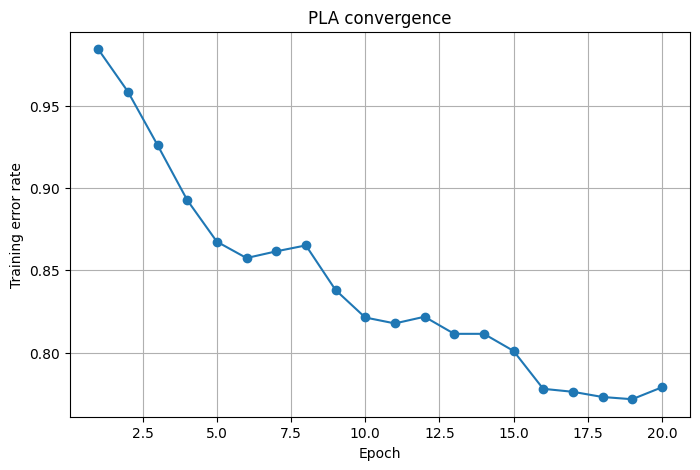

PLA classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.21      0.27      0.24        11
           2       0.00      0.00      0.00        11
           3       1.00      0.09      0.17        11
           4       0.00      0.00      0.00        11
           5       0.00      0.00      0.00        11
           6       0.00      0.00      0.00        11
           7       0.00      0.00      0.00        11
           8       0.03      0.91      0.06        11
           9       0.00      0.00      0.00        11
           A       0.00      0.00      0.00        11
           B       0.25      0.18      0.21        11
           C       0.78      0.64      0.70        11
           D       0.00      0.00      0.00        11
           E       0.50      0.09      0.15        11
           F       0.00      0.00      0.00        11
           G       0.67      0.18      0.29        11


In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pla.errors_) + 1), pla.errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training error rate")
plt.title("PLA convergence")
plt.grid(True)
plt.savefig(FIGURES_DIR / 'pla_convergence.png', dpi=300, bbox_inches='tight')
plt.show()
print("PLA classification report:")
print(classification_report(
    y_test, pla_pred,
    labels=np.arange(62),
    target_names=CLASS_NAMES,
    zero_division=0
))


# Part B — Model B: MLP and Hyperparameter Tuning

The assignment specifically asks us to vary:
- activation function;
- optimizer;
- learning rate;
- batch size;
- hidden-layer configuration.

The MLP uses cross-entropy loss for multiclass classification and backpropagation through the selected hidden layers.

To keep the notebook practical, a compact but systematic validation experiment is used rather than an unnecessarily large exhaustive grid.

In [8]:
# Compact systematic tuning experiment.
# Each configuration is evaluated on the validation set.

tuning_configs = [
    {"hidden_layer_sizes": (128,), "activation": "relu", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 32},
    {"hidden_layer_sizes": (128,), "activation": "relu", "solver": "adam", "learning_rate_init": 0.01,  "batch_size": 32},
    {"hidden_layer_sizes": (128,), "activation": "tanh", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 32},
    {"hidden_layer_sizes": (128,), "activation": "tanh", "solver": "adam", "learning_rate_init": 0.01,  "batch_size": 32},
    {"hidden_layer_sizes": (128,), "activation": "relu", "solver": "sgd",  "learning_rate_init": 0.001, "batch_size": 32},
    {"hidden_layer_sizes": (128,), "activation": "relu", "solver": "sgd",  "learning_rate_init": 0.01,  "batch_size": 32},
    {"hidden_layer_sizes": (128,), "activation": "relu", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 64},
    {"hidden_layer_sizes": (128, 64), "activation": "relu", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 32},
    {"hidden_layer_sizes": (256,), "activation": "relu", "solver": "adam", "learning_rate_init": 0.001, "batch_size": 32},
]

tuning_results = []
tuned_models = {}

for i, cfg in enumerate(tuning_configs, start=1):
    model = MLPClassifier(
        **cfg,
        max_iter=60,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=8,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    row = {
        "Trial": i,
        **cfg,
        "Validation Accuracy": accuracy_score(y_val, pred),
        "Validation Macro F1": f1_score(y_val, pred, average="macro", zero_division=0),
        "Epochs": model.n_iter_,
        "Final Training Loss": model.loss_curve_[-1]
    }

    tuning_results.append(row)
    tuned_models[i] = model

tuning_df = pd.DataFrame(tuning_results).sort_values(
    "Validation Macro F1", ascending=False
).reset_index(drop=True)

tuning_df


,Trial,hidden_layer_sizes,activation,solver,learning_rate_init,batch_size,Validation Accuracy,Validation Macro F1,Epochs,Final Training Loss
0,3,"(128,)",tanh,adam,0.001,32,0.277344,0.244304,60,2.549183
1,5,"(128,)",relu,sgd,0.001,32,0.201172,0.162739,41,3.143729
2,1,"(128,)",relu,adam,0.001,32,0.019531,0.002004,11,4.128505
3,7,"(128,)",relu,adam,0.001,64,0.019531,0.001182,11,4.074872
4,6,"(128,)",relu,sgd,0.010,32,0.015625,0.000500,10,4.127932
5,9,"(256,)",relu,adam,0.001,32,0.015625,0.000500,10,4.128324
6,2,"(128,)",relu,adam,0.010,32,0.015625,0.000496,10,4.131065
7,4,"(128,)",tanh,adam,0.010,32,0.015625,0.000496,13,4.475329
8,8,"(128, 64)",relu,adam,0.001,32,0.015625,0.000496,10,4.128239


In [9]:
# Best configuration based on validation Macro F1.
best_trial = int(tuning_df.iloc[0]["Trial"])
best_config = tuning_configs[best_trial - 1]

print("Selected trial:", best_trial)
print("Selected hyperparameters:")
for k, v in best_config.items():
    print(f"  {k}: {v}")

print("\nReason for selection:")
print("The configuration with the highest validation Macro F1 is selected,")
print("which treats all 62 character classes equally during model selection.")


Selected trial: 3
Selected hyperparameters:
  hidden_layer_sizes: (128,)
  activation: tanh
  solver: adam
  learning_rate_init: 0.001
  batch_size: 32

Reason for selection:
The configuration with the highest validation Macro F1 is selected,
which treats all 62 character classes equally during model selection.


## 4. Final tuned MLP

After choosing the hyperparameters using the validation set, the final MLP is retrained on the combined **training + validation** data and evaluated once on the untouched test set.

In [10]:
X_train_final = np.vstack([X_train, X_val])
y_train_final = np.concatenate([y_train, y_val])

final_mlp = MLPClassifier(
    **best_config,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=10,
    random_state=RANDOM_STATE
)

final_mlp.fit(X_train_final, y_train_final)

mlp_pred = final_mlp.predict(X_test)
mlp_prob = final_mlp.predict_proba(X_test)

mlp_metrics = evaluate_model(y_test, mlp_pred, "Tuned MLP")
results_df = pd.DataFrame([pla_metrics, mlp_metrics])

results_df


,Model,Accuracy,Precision,Recall,F1
0,PLA,0.102639,0.198341,0.102639,0.094756
1,Tuned MLP,0.146628,0.145418,0.146628,0.116541


In [11]:
print("Tuned MLP classification report:")
print(classification_report(
    y_test, mlp_pred,
    labels=np.arange(62),
    target_names=CLASS_NAMES,
    zero_division=0
))


Tuned MLP classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        11
           2       0.67      0.18      0.29        11
           3       0.00      0.00      0.00        11
           4       0.09      0.09      0.09        11
           5       0.08      0.09      0.09        11
           6       0.00      0.00      0.00        11
           7       0.00      0.00      0.00        11
           8       0.43      0.27      0.33        11
           9       0.33      0.09      0.14        11
           A       0.21      0.36      0.27        11
           B       0.43      0.55      0.48        11
           C       0.19      0.55      0.29        11
           D       0.25      0.09      0.13        11
           E       0.00      0.00      0.00        11
           F       0.50      0.36      0.42        11
           G       0.19      0.36      0.25     

# Part C — Confusion Matrices

Because there are 62 classes, the confusion matrices are large. The heatmaps are therefore plotted at a compact scale with class labels.

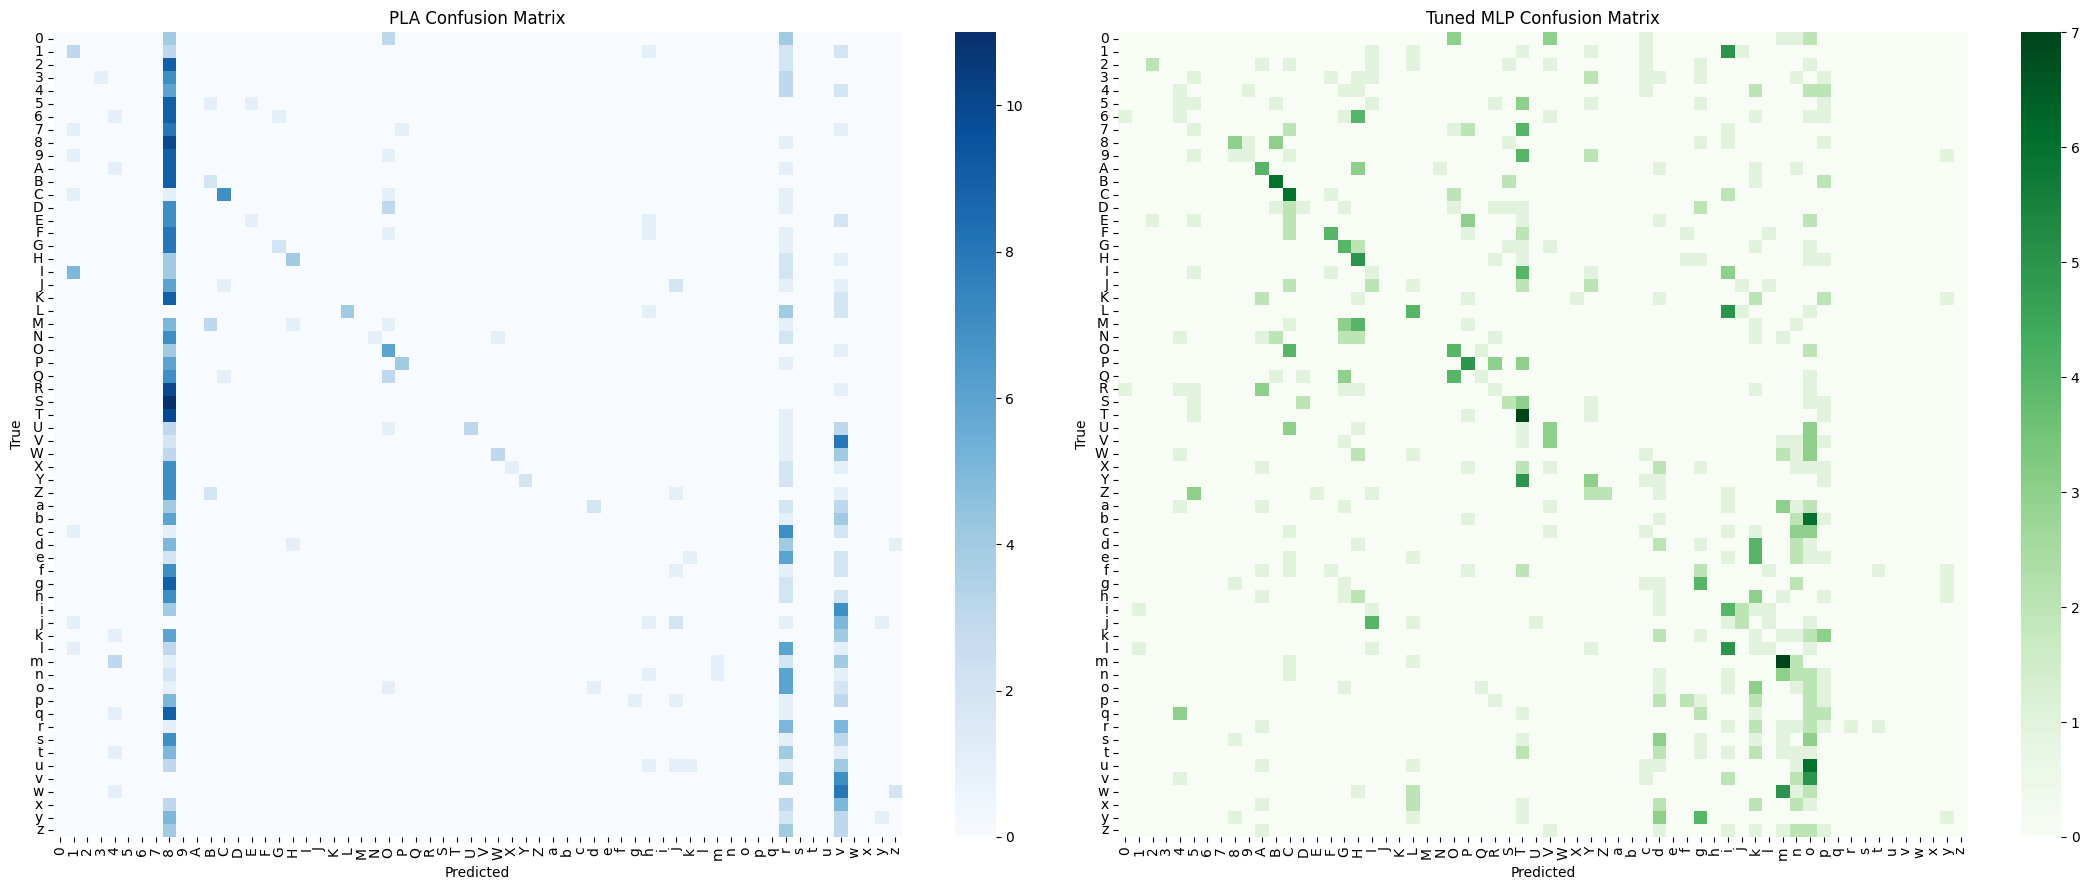

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
cm_pla = confusion_matrix(y_test, pla_pred, labels=np.arange(62))
cm_mlp = confusion_matrix(y_test, mlp_pred, labels=np.arange(62))
sns.heatmap(cm_pla, cmap="Blues", ax=axes[0], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title("PLA Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
sns.heatmap(cm_mlp, cmap="Greens", ax=axes[1], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title("Tuned MLP Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


# Part D — ROC Curves

For the 62-class problem, ROC is computed using a one-vs-rest formulation.

The notebook reports:
- **micro-average ROC**, which weights every class/sample decision;
- **macro-average ROC**, which gives equal importance to each class.

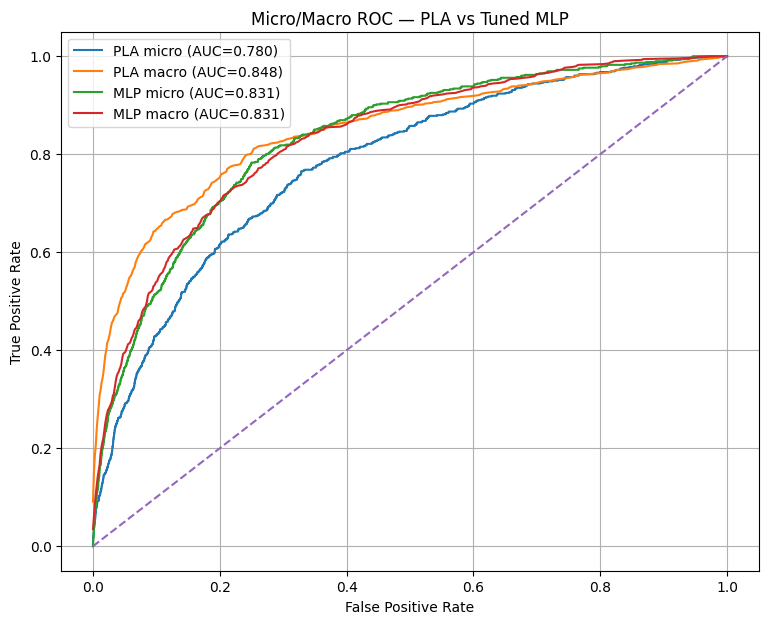

PLA micro AUC : 0.78
PLA macro AUC : 0.8481
MLP micro AUC : 0.8311
MLP macro AUC : 0.8314


In [13]:
def multiclass_roc_data(y_true, y_score, n_classes=62):
    y_bin = label_binarize(y_true, classes=np.arange(n_classes))
    fpr = {}
    tpr = {}
    roc_auc = {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    # Micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    # Macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    return fpr, tpr, roc_auc
# PLA does not naturally produce calibrated probabilities.
# We use its class scores as one-vs-rest decision scores.
pla_scores = pla.predict_scores(X_test)
pla_fpr, pla_tpr, pla_auc = multiclass_roc_data(y_test, pla_scores)
mlp_fpr, mlp_tpr, mlp_auc = multiclass_roc_data(y_test, mlp_prob)
plt.figure(figsize=(9, 7))
plt.plot(pla_fpr["micro"], pla_tpr["micro"],
         label=f"PLA micro (AUC={pla_auc['micro']:.3f})")
plt.plot(pla_fpr["macro"], pla_tpr["macro"],
         label=f"PLA macro (AUC={pla_auc['macro']:.3f})")
plt.plot(mlp_fpr["micro"], mlp_tpr["micro"],
         label=f"MLP micro (AUC={mlp_auc['micro']:.3f})")
plt.plot(mlp_fpr["macro"], mlp_tpr["macro"],
         label=f"MLP macro (AUC={mlp_auc['macro']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro/Macro ROC — PLA vs Tuned MLP")
plt.legend()
plt.grid(True)
plt.savefig(FIGURES_DIR / 'roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("PLA micro AUC :", round(pla_auc["micro"], 4))
print("PLA macro AUC :", round(pla_auc["macro"], 4))
print("MLP micro AUC :", round(mlp_auc["micro"], 4))
print("MLP macro AUC :", round(mlp_auc["macro"], 4))


# Part E — Convergence Curves

The PLA convergence curve uses its **training error rate per epoch**.

The MLP convergence curve uses the **training loss recorded during backpropagation** by `MLPClassifier`.

These are related but not numerically identical quantities, so the distinction should be mentioned in the report.

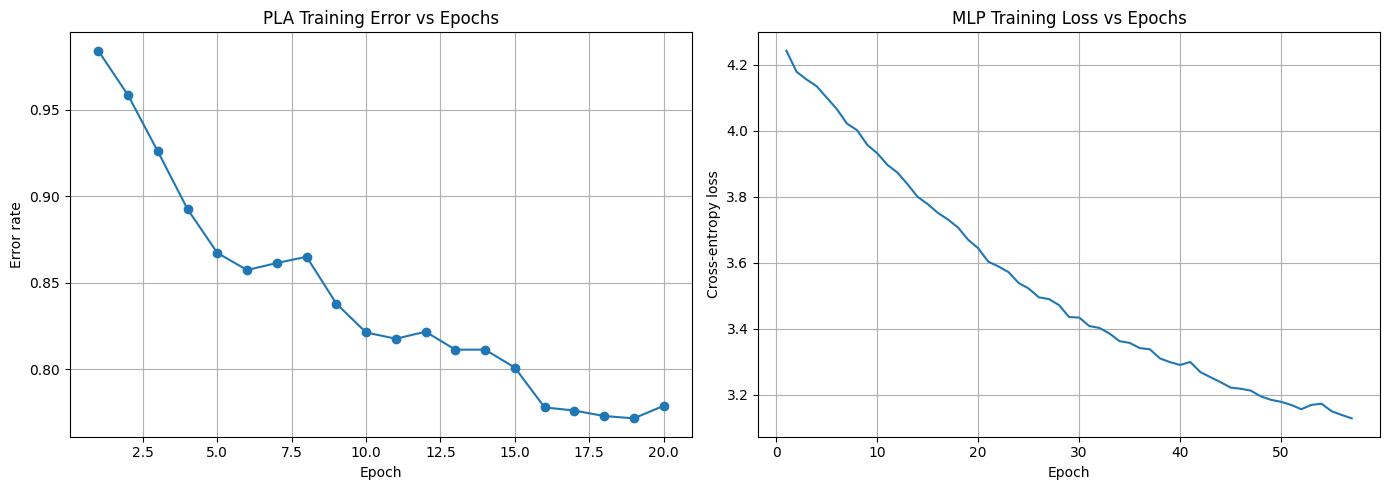

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(pla.errors_) + 1), pla.errors_, marker="o")
axes[0].set_title("PLA Training Error vs Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Error rate")
axes[0].grid(True)
axes[1].plot(range(1, len(final_mlp.loss_curve_) + 1), final_mlp.loss_curve_)
axes[1].set_title("MLP Training Loss vs Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross-entropy loss")
axes[1].grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'convergence_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# Part F — Hyperparameter Impact

To make the tuning analysis easier to discuss in the report, the following table groups the validation results by individual hyperparameters.

This does **not** claim that a hyperparameter acts independently of the others; it simply provides an easy descriptive comparison of the trials that were run.

In [15]:
display_cols = [
    "Trial", "activation", "solver", "learning_rate_init",
    "batch_size", "hidden_layer_sizes",
    "Validation Accuracy", "Validation Macro F1", "Epochs"
]

tuning_df[display_cols]


,Trial,activation,solver,learning_rate_init,batch_size,hidden_layer_sizes,Validation Accuracy,Validation Macro F1,Epochs
0,3,tanh,adam,0.001,32,"(128,)",0.277344,0.244304,60
1,5,relu,sgd,0.001,32,"(128,)",0.201172,0.162739,41
2,1,relu,adam,0.001,32,"(128,)",0.019531,0.002004,11
3,7,relu,adam,0.001,64,"(128,)",0.019531,0.001182,11
4,6,relu,sgd,0.010,32,"(128,)",0.015625,0.000500,10
5,9,relu,adam,0.001,32,"(256,)",0.015625,0.000500,10
6,2,relu,adam,0.010,32,"(128,)",0.015625,0.000496,10
7,4,tanh,adam,0.010,32,"(128,)",0.015625,0.000496,13
8,8,relu,adam,0.001,32,"(128, 64)",0.015625,0.000496,10


In [16]:
# Simple grouped summaries for discussion
print("Average validation Macro F1 by activation:")
display(tuning_df.groupby("activation")["Validation Macro F1"].mean().sort_values(ascending=False).to_frame())

print("Average validation Macro F1 by optimizer:")
display(tuning_df.groupby("solver")["Validation Macro F1"].mean().sort_values(ascending=False).to_frame())

print("Average validation Macro F1 by batch size:")
display(tuning_df.groupby("batch_size")["Validation Macro F1"].mean().sort_values(ascending=False).to_frame())

print("Average validation Macro F1 by learning rate:")
display(tuning_df.groupby("learning_rate_init")["Validation Macro F1"].mean().sort_values(ascending=False).to_frame())


Average validation Macro F1 by activation:


,Validation Macro F1
activation,
tanh,0.122400
relu,0.023988


Average validation Macro F1 by optimizer:


,Validation Macro F1
solver,
sgd,0.08162
adam,0.03564


Average validation Macro F1 by batch size:


,Validation Macro F1
batch_size,
32,0.051442
64,0.001182


Average validation Macro F1 by learning rate:


,Validation Macro F1
learning_rate_init,
0.001,0.068538
0.010,0.000498


# Part G — A/B Comparison

## Questions to answer in the report

### 1. Why does PLA underperform compared to MLP?
Relate the result to the model assumptions: PLA produces linear decision boundaries, while the MLP can learn nonlinear boundaries through hidden layers and nonlinear activations.

### 2. Which hyperparameters had the most impact?
Use the actual validation table and grouped summaries above. Avoid claiming an effect that is not supported by the observed trials.

### 3. Did SGD vs Adam affect convergence?
Compare the validation metrics and convergence behavior of the SGD and Adam trials.

### 4. Did adding more hidden layers always improve results?
Compare the `(128,)` and `(128, 64)` trials. The answer should be based on the observed validation results rather than assuming that a deeper network must be better.

### 5. Did MLP show overfitting?
Compare training loss, validation behavior during early stopping, and the final test performance. Possible mitigation methods include early stopping, regularization, reducing model complexity, or obtaining more training data.

Final A/B comparison:


,Model,Accuracy,Precision,Recall,F1
0,PLA,0.1026,0.1983,0.1026,0.0948
1,Tuned MLP,0.1466,0.1454,0.1466,0.1165



Chosen MLP configuration:


,hidden_layer_sizes,activation,solver,learning_rate_init,batch_size
0,"(128,)",tanh,adam,0.001,32


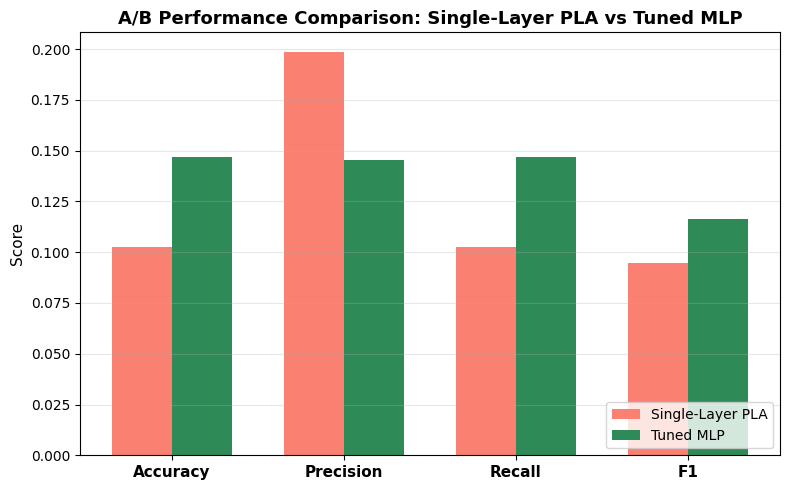

In [17]:
# Compact final comparison table
comparison = results_df.copy()
comparison["Accuracy"] = comparison["Accuracy"].round(4)
comparison["Precision"] = comparison["Precision"].round(4)
comparison["Recall"] = comparison["Recall"].round(4)
comparison["F1"] = comparison["F1"].round(4)
print("Final A/B comparison:")
display(comparison)
print("\nChosen MLP configuration:")
display(pd.DataFrame([best_config]))
plt.figure(figsize=(8, 5))
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics_to_plot))
width = 0.35
plt.bar(x - width/2, [results_df.loc[0, m] for m in metrics_to_plot], width, label="Single-Layer PLA", color="salmon")
plt.bar(x + width/2, [results_df.loc[1, m] for m in metrics_to_plot], width, label="Tuned MLP", color="seagreen")
plt.xticks(x, metrics_to_plot, fontsize=11, fontweight='bold')
plt.ylabel("Score", fontsize=11)
plt.title("A/B Performance Comparison: Single-Layer PLA vs Tuned MLP", fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ab_comparison_bar.png", dpi=300, bbox_inches="tight")
plt.show()


# Report Checklist

Use the outputs from this notebook to prepare the final report:

- [x] Aim and Objective
- [x] Preprocessing Steps
- [x] PLA Implementation and Results
- [x] MLP Implementation and Results
- [x] Justification for Chosen Hyperparameters
- [x] A/B Comparison (PLA vs MLP)
- [x] Confusion Matrices and ROC Curves
- [x] Observations and Analysis

**Important:** The numerical values in the report should be taken from the notebook output after execution, rather than being hard-coded beforehand.